<a href="https://colab.research.google.com/github/MaritRokx/Explainable-AI/blob/main/ExplainableAIFinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install shap dice-ml scikit-learn pandas numpy matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 39.1 MB/s eta 0:00:00


In [ ]:
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OrdinalEncoder
import pandas as pd
import numpy as np
import shap
import dice_ml

In [ ]:
# Define columns
columns = ['age', 'workclass', 'fnlwgt', 'education', 'education-num',
           'marital-status', 'occupation', 'relationship', 'race', 'sex',
           'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']

# Select train and test data
train_df = pd.read_csv('adult.data', names=columns, skipinitialspace=True, na_values='?')
test_df = pd.read_csv('adult.test', names=columns, skipinitialspace=True, skiprows=1, na_values='?')

# Removes rows with NaNs in it
train_df.dropna(inplace=True)
test_df.dropna(inplace=True)

# Cleans the data, it removes an extra period at the end of the labels
train_df['income'] = train_df['income'].replace({'<=50K': 0, '>50K': 1})
test_df['income'] = test_df['income'].replace({'<=50K.': 0, '>50K.': 1})

# Identify the categorical columns
categorical_cols = train_df.select_dtypes(include=['object']).columns.tolist()

# Encodes categories, handles new or unseen values as -1
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

# Fit and transform on the training data
train_df[categorical_cols] = encoder.fit_transform(train_df[categorical_cols])

# Fit and transform on the test data
test_df[categorical_cols] = encoder.transform(test_df[categorical_cols])

# Remove the target 'income' from features and ensure labels are integer type
X_train = train_df.drop('income', axis=1)
labels_train = train_df['income'].astype(int)
X_test = test_df.drop('income', axis=1)
labels_test = test_df['income'].astype(int)


/tmp/ipykernel_23771/2009222711.py:15: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train_df['income'] = train_df['income'].replace({'<=50K': 0, '>50K': 1})
/tmp/ipykernel_23771/2009222711.py:16: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test_df['income'] = test_df['income'].replace({'<=50K.': 0, '>50K.': 1})


In [ ]:
# Fits a random forest classifier on the training data.
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, labels_train)

# Makes a predictor
y_pred = rf.predict(X_test)
print("Accuracy: ", accuracy_score(labels_test, y_pred))

Accuracy:  0.850796812749004


  0%|          | 0/6032 [00:00<?, ?it/s]

Average predicted output (base value):  0.0


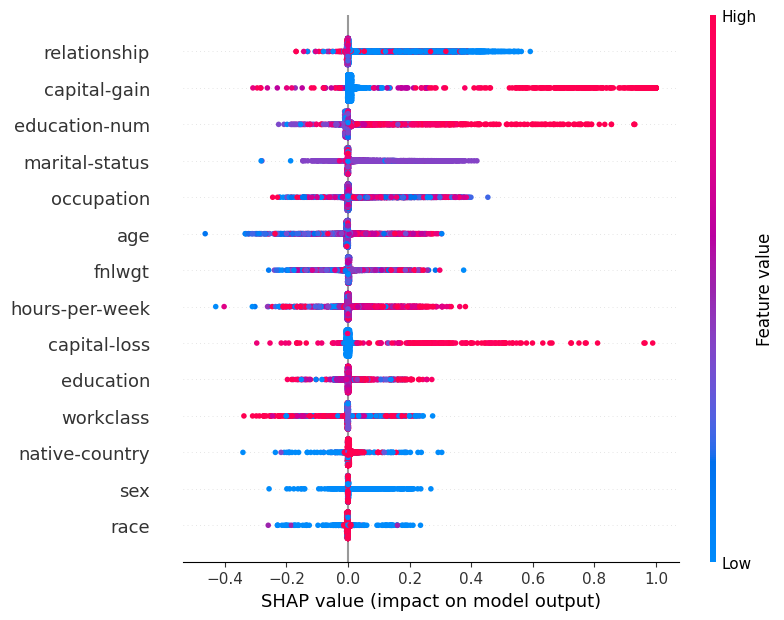

In [ ]:
# Generates explainer for SHAP
explainer = shap.KernelExplainer(rf.predict, shap.kmeans(X_train, 10))

# Calculates for 20% of the training data
nb_points_explain = round(0.2 * X_train.shape[0])
X_explain = X_train.iloc[0:nb_points_explain, :]

# Generate feature attribution scores showing how much each input affected the model output
shap_values = explainer(X_explain)

print("Average predicted output (base value): ", shap_values.base_values[0])

shap.plots.beeswarm(shap_values, max_display=15)

In [ ]:
# Check the gender distribution in the subset used for SHAP
gender_counts = X_explain['sex'].value_counts()

print(f"Men (1): {gender_counts.get(1, 0)}")
print(f"Women (0): {gender_counts.get(0, 0)}")

Men (1): 4110
Women (0): 1922


In [ ]:
# Create a copy of the training data including the target column for the DiCE model
dice_train_df = X_train.copy()
dice_train_df['income'] = labels_train

continuous_features = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

# Create the data interface for DiCE, distinguishing between numerical and categorical data
d = dice_ml.Data(
    dataframe=dice_train_df,
    continuous_features=continuous_features,
    outcome_name='income'
)

# Initializes DiCE explainer with the trained model and random search strategy
m = dice_ml.Model(model=rf, backend="sklearn")
exp_dice = dice_ml.Dice(d, m, method="random")

# Number of instances we test on, whole dataset is too big
num_instances_to_test = 1000
query_instances = X_test.iloc[0:num_instances_to_test]

success_count = 0

# Loops through test samples to see if changing 'sex' alone flips the model's prediction
for i in range(num_instances_to_test):
    # gets the current prediction of this person (instance)
    single_instance = query_instances.iloc[i:i+1]
    orig_pred = rf.predict(single_instance)[0]

    try:
        # Flips the prediction by changing "sex"
        dice_cf = exp_dice.generate_counterfactuals(
            single_instance,
            total_CFs=1,
            desired_class="opposite",
            features_to_vary=['sex']
        )

        # if a counterfactual is found, add 1 to success_count as there is bias
        dice_cf.visualize_as_dataframe(show_only_changes=True)
        success_count += 1

    except Exception as e:
        # If exception is found, we do nothing
        pass

print(f"Summary: Found {success_count} instances out of {num_instances_to_test} where changing ONLY 'sex' flipped the income prediction.")

  0%|          | 0/1 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/dice_ml/explainer_interfaces/dice_random.py:116: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1.0' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  candidate_cfs.at[k, selected_features[k][0]] = random_instances.at[k, selected_features[k][0]]
100%|██████████| 1/1 [00:00<00:00, 15.59it/s]


No Counterfactuals found for the given configuration, perhaps try with different parameters... ; total time taken: 00 min 00 sec


  0%|          | 0/1 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/dice_ml/explainer_interfaces/dice_random.py:116: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1.0' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  candidate_cfs.at[k, selected_features[k][0]] = random_instances.at[k, selected_features[k][0]]
100%|██████████| 1/1 [00:00<00:00, 14.48it/s]


No Counterfactuals found for the given configuration, perhaps try with different parameters... ; total time taken: 00 min 00 sec


  0%|          | 0/1 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/dice_ml/explainer_interfaces/dice_random.py:116: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.0' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  candidate_cfs.at[k, selected_features[k][0]] = random_instances.at[k, selected_features[k][0]]
100%|██████████| 1/1 [00:00<00:00,  7.74it/s]


...

No Counterfactuals found for the given configuration, perhaps try with different parameters... ; total time taken: 00 min 00 sec


  0%|          | 0/1 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/dice_ml/explainer_interfaces/dice_random.py:116: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.0' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  candidate_cfs.at[k, selected_features[k][0]] = random_instances.at[k, selected_features[k][0]]
100%|██████████| 1/1 [00:00<00:00,  8.87it/s]


No Counterfactuals found for the given configuration, perhaps try with different parameters... ; total time taken: 00 min 00 sec


  0%|          | 0/1 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/dice_ml/explainer_interfaces/dice_random.py:116: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1.0' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  candidate_cfs.at[k, selected_features[k][0]] = random_instances.at[k, selected_features[k][0]]
100%|██████████| 1/1 [00:00<00:00, 10.33it/s]

No Counterfactuals found for the given configuration, perhaps try with different parameters... ; total time taken: 00 min 00 sec
Summary: Found 68 instances out of 1000 where changing ONLY 'sex' flipped the income prediction.
